In [ ]:
import pandas as pd

BASE_PATH = "ETAPA 1 - CONSTRUCCIÓN BASE DE DATOS/DATA CENSO/63_Quindio_CSV/"

paths = {
    "PERSONAS": BASE_PATH + "CNPV2018_5PER_A2_63.CSV",
    "HOGARES": BASE_PATH + "CNPV2018_2HOG_A2_63.CSV",
    "VIVIENDAS": BASE_PATH + "CNPV2018_1VIV_A2_63.CSV",
    "FALLECIDOS": BASE_PATH + "CNPV2018_3FALL_A2_63.CSV",
    "MGN": BASE_PATH + "CNPV2018_MGN_A2_63.CSV",
}
def read_df(path):
    return pd.read_csv(path, sep=",", encoding="latin-1", low_memory=False)

def filter_armenia(df):
    dpto = df["U_DPTO"].astype(str).str.zfill(2)
    mpio = df["U_MPIO"].astype(str).str.zfill(3)
    return df[(dpto == "63") & (mpio == "001")].copy()

dfs_arm = {}

for name, path in paths.items():
    df = read_df(path)
    df_arm = filter_armenia(df)
    dfs_arm[name] = df_arm
    print(name, df.shape, "-> Armenia:", df_arm.shape)


PERSONAS (509640, 48) -> Armenia: (275641, 48)
HOGARES (174475, 13) -> Armenia: (95610, 13)
VIVIENDAS (199551, 30) -> Armenia: (112488, 30)
FALLECIDOS (3386, 11) -> Armenia: (1634, 11)
MGN (199551, 14) -> Armenia: (112488, 14)


Unificar llaves

In [18]:
def norm_keys(df):
    df["U_DPTO"] = df["U_DPTO"].astype(str).str.zfill(2)
    df["U_MPIO"] = df["U_MPIO"].astype(str).str.zfill(3)
    df["COD_ENCUESTAS"] = df["COD_ENCUESTAS"].astype(str)
    df["U_VIVIENDA"] = df["U_VIVIENDA"].astype(str)
    return df

for k in dfs_arm:
    dfs_arm[k] = norm_keys(dfs_arm[k])


In [19]:
# --- llaves de unicidad esperada ---
k_viv = ["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA"]
k_hog = ["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA","H_NROHOG"]
k_mgn = ["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA"]

# --- deduplicación defensiva (evita duplicados malos) ---
dfs_arm["VIVIENDAS"] = dfs_arm["VIVIENDAS"].drop_duplicates(subset=k_viv, keep="first")
dfs_arm["HOGARES"]   = dfs_arm["HOGARES"].drop_duplicates(subset=k_hog, keep="first")
dfs_arm["MGN"]       = dfs_arm["MGN"].drop_duplicates(subset=k_mgn, keep="first")


Personas + hogares

In [20]:
df_PH = dfs_arm["PERSONAS"].merge(
    dfs_arm["HOGARES"],
    left_on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA","P_NROHOG"],
    right_on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA","H_NROHOG"],
    how="left",
    suffixes=("", "_H")
)

df_PH.shape


(275641, 56)

agregar viviendas

In [21]:
df_PHV = df_PH.merge(
    dfs_arm["VIVIENDAS"],
    on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA"],
    how="left",
    suffixes=("", "_V")
)

df_PHV.shape


(275641, 81)

MGN (geografía)

In [22]:
df_master = df_PHV.merge(
    dfs_arm["MGN"],
    on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA"],
    how="left"
)

df_master.shape


(275641, 90)

In [23]:
df_master.isna().mean().sort_values(ascending=False).head(15)


UVA1_COD_AREAPROT    1.000000
UVA2_CODTER          1.000000
UVA1_TIPOTER         1.000000
PA21_COD_VITSA       0.999985
PA22_COD_KUMPA       0.999985
PA12_CLAN            0.999978
PB1_QOTRAS_LENG      0.998701
PA1_ENTIENDE         0.995821
L_EXISTEHOG          0.993209
L_TIPO_INST          0.993209
L_TOT_PERL           0.993209
PA11_COD_ETNIA       0.993118
PA_HABLA_LENG        0.993092
PB_OTRAS_LENG        0.993092
HA_NRO_FALL          0.982887
dtype: float64

In [24]:
df_master["P_SEXO"].value_counts(normalize=True)
df_master["P_EDADR"].value_counts().sort_index()


P_EDADR
1     14217
2     15046
3     17424
4     21345
5     23259
6     21522
7     19446
8     19923
9     17203
10    17438
11    18983
12    18078
13    15745
14    12451
15     9056
16     6421
17     4327
18     2451
19      960
20      259
21       87
Name: count, dtype: int64

Columnas importantes

In [25]:
geo_cols = [
    "U_DPTO","U_MPIO","UA_CLASE",
    "UA1_LOCALIDAD","U_SECT_URB","U_SECC_URB","U_MZA",
    "COD_DANE_ANM"
]

demo_cols = [
    "P_SEXO","P_EDADR","P_PARENTESCOR"
]

edu_cols = [
    "P_ALFABETA","PA_ASISTENCIA","P_NIVEL_ANOSR"
]

salud_cols = [
    "P_ENFERMO","PA_LO_ATENDIERON","PA1_CALIDAD_SERV"
]

trab_cols = ["P_TRABAJO"]

vivienda_cols = [
    "V_MAT_PARED","V_MAT_PISO","V_TIPO_VIV","V_CON_OCUP"
]

serv_cols = [
    "VA_EE","VB_ACU","VC_ALC","VD_GAS","VE_RECBAS","VF_INTERNET"
]

hacin_cols = [
    "H_NRO_CUARTOS","H_NRO_DORMIT","HA_TOT_PER"
]

key_cols = ["U_VIVIENDA","P_NROHOG","P_NRO_PER","COD_ENCUESTAS",]

keep_cols = list(set(
    geo_cols + demo_cols + edu_cols + salud_cols +
    trab_cols + vivienda_cols + serv_cols + hacin_cols + key_cols
))


In [26]:
existing = set(df_master.columns)

kept = sorted(existing.intersection(keep_cols))
removed = sorted(existing - set(kept))

print("COLUMNAS QUE SE QUEDAN:", len(kept))
print("COLUMNAS ELIMINADAS:", len(removed))


COLUMNAS QUE SE QUEDAN: 35
COLUMNAS ELIMINADAS: 55


In [27]:
import pandas as pd

df_report = pd.DataFrame({
    "columna": kept + removed,
    "estado": ["SE QUEDA"]*len(kept) + ["SE ELIMINA"]*len(removed)
})

df_report["bloque"] = df_report["columna"].map(
    lambda c:
        "Geografía" if c in geo_cols else
        "Demografía" if c in demo_cols else
        "Educación" if c in edu_cols else
        "Salud" if c in salud_cols else
        "Trabajo" if c in trab_cols else
        "Vivienda" if c in vivienda_cols else
        "Servicios" if c in serv_cols else
        "Hacinamiento" if c in hacin_cols else
        "Llaves" if c in key_cols else
        "Otros"
)

df_report.sort_values(["estado","bloque","columna"]).head(30)


,columna,estado,bloque
35,CONDICION_FISICA,SE ELIMINA,Otros
36,HA_NRO_FALL,SE ELIMINA,Otros
37,H_AGUA_COCIN,SE ELIMINA,Otros
38,H_DONDE_PREPALIM,SE ELIMINA,Otros
39,H_NROHOG,SE ELIMINA,Otros
40,L_EXISTEHOG,SE ELIMINA,Otros
41,L_TIPO_INST,SE ELIMINA,Otros
42,L_TOT_PERL,SE ELIMINA,Otros
43,PA11_COD_ETNIA,SE ELIMINA,Otros
44,PA12_CLAN,SE ELIMINA,Otros


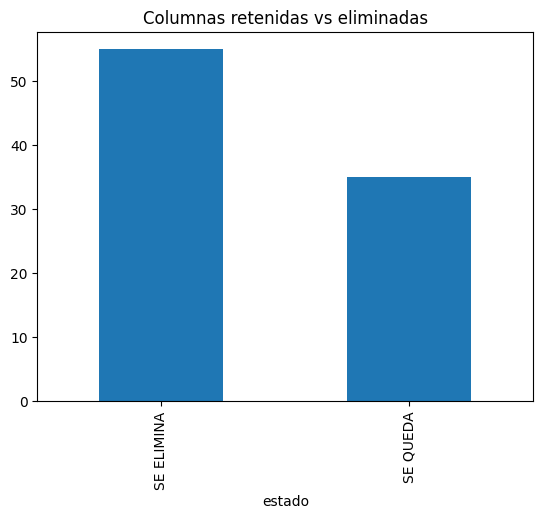

In [28]:
import matplotlib.pyplot as plt

df_report["estado"].value_counts().plot(kind="bar")
plt.title("Columnas retenidas vs eliminadas")
plt.show()


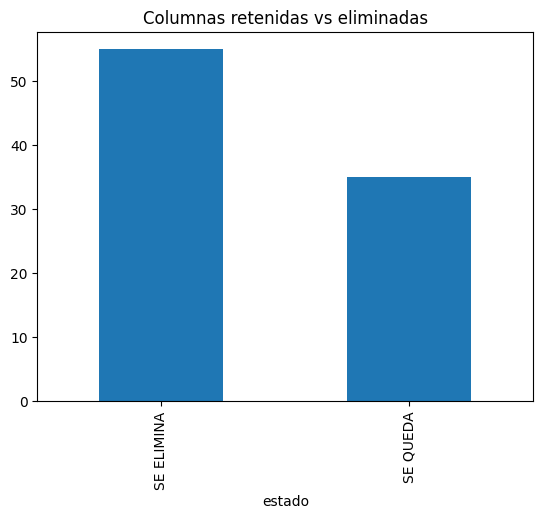

In [29]:
import matplotlib.pyplot as plt

df_report["estado"].value_counts().plot(kind="bar")
plt.title("Columnas retenidas vs eliminadas")
plt.show()


In [30]:
display(df_report[df_report.estado=="SE QUEDA"])
display(df_report[df_report.estado=="SE ELIMINA"])


,columna,estado,bloque
0,COD_DANE_ANM,SE QUEDA,Geografía
1,COD_ENCUESTAS,SE QUEDA,Llaves
2,HA_TOT_PER,SE QUEDA,Hacinamiento
3,H_NRO_CUARTOS,SE QUEDA,Hacinamiento
4,H_NRO_DORMIT,SE QUEDA,Hacinamiento
5,PA1_CALIDAD_SERV,SE QUEDA,Salud
6,PA_ASISTENCIA,SE QUEDA,Educación
7,PA_LO_ATENDIERON,SE QUEDA,Salud
8,P_ALFABETA,SE QUEDA,Educación
9,P_EDADR,SE QUEDA,Demografía


,columna,estado,bloque
35,CONDICION_FISICA,SE ELIMINA,Otros
36,HA_NRO_FALL,SE ELIMINA,Otros
37,H_AGUA_COCIN,SE ELIMINA,Otros
38,H_DONDE_PREPALIM,SE ELIMINA,Otros
39,H_NROHOG,SE ELIMINA,Otros
40,L_EXISTEHOG,SE ELIMINA,Otros
41,L_TIPO_INST,SE ELIMINA,Otros
42,L_TOT_PERL,SE ELIMINA,Otros
43,PA11_COD_ETNIA,SE ELIMINA,Otros
44,PA12_CLAN,SE ELIMINA,Otros


In [31]:
# Base reducida (recomendado)
df_master_reducido = df_master.loc[:, kept].copy()

print("Original:", df_master.shape)
print("Reducido:", df_master_reducido.shape)


Original: (275641, 90)
Reducido: (275641, 35)


In [34]:
df_master_reducido.to_csv(
    "ETAPA 1 - CONSTRUCCIÓN BASE DE DATOS/outputs/armenia_base_consolidada_reducida.csv.gz",
    index=False,
    compression="gzip"
)

print("Archivo guardado")

Archivo guardado
